In [1]:
# Imports #

import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, ReLU, MaxPool2D, BatchNormalization, Flatten, Dense
from tensorflow.keras.models import Model

2026-04-05 19:04:45.898828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Constants #

GAUSSIAN_X = 48
GAUSSIAN_Y = 48

MIN_STD_X = 5
MAX_STD_X = 11

MIN_STD_Y = 5
MAX_STD_Y = 11

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.2
MAX_INTENSITY = 0.8

# TF

In [3]:
# Tensorflow Functions #

scaling_arr = np.array([48.0, 48.0, 24.0, 24.0, np.pi/2], dtype=np.float32)

# huber loss
def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred * scaling_arr + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

In [4]:
# Load Model #
MODEL_NAME = '[Gaussian]_[Generated]_[48].keras'


gaussian = tf.keras.models.load_model(
    f'/mnt/Research/Rheed-Gaussian/Models/{MODEL_NAME}',
    custom_objects={"dice_loss": dice_loss}
)


gaussian.summary()

I0000 00:00:1775441091.440332   89996 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4090 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "gaussian"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ InputLayer (InputLayer)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 6)      │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 46, 46, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 8)        │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 9, 8)        │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 10)       │           730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 10)       │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 2, 2, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,023 (19.62 KB)

 Trainable params: 1,658 (6.48 KB)

 Non-trainable params: 48 (192.00 B)

 Optimizer params: 3,317 (12.96 KB)

# HLS4ML

In [5]:
# HLS4ML Config #
 
import hls4ml
from hls4ml.utils import config_from_keras_model

config = config_from_keras_model(gaussian, granularity='name', backend='Vitis')
config['Model']['Strategy'] = 'Latency'
config['Model']['ReuseFactor'] = 1
hls_model = hls4ml.converters.convert_from_keras_model(
    gaussian,
    hls_config=config,
    output_dir='../gaussian_hls4ml',
    io_type='io_stream',
    backend='Vitis',
    default_precision='fixed<32,16>',
    part='xcku035-fbva676-2-e',
    project_name='gaussian'
)

v2 handler used for layer batch_normalization
v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2
v2 handler used for layer batch_normalization
v2 handler used for layer batch_normalization_1
v2 handler used for layer batch_normalization_2


In [6]:
# Compile Model #

hls_model.compile()

# Model Comparison

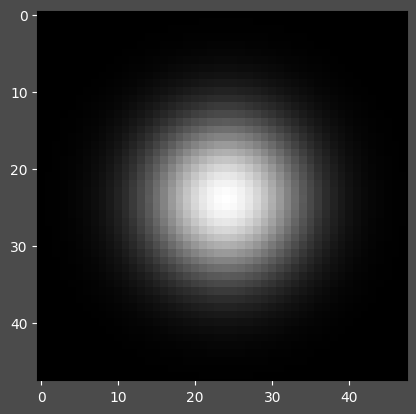

In [18]:
# Read from Stim file #

with open('/mnt/Research/RHEED/04_ref_design/sim/PP_data_gaus.dat', 'r') as f:
    data = f.read()

hex_values = data.split()

int_values = [int(x, 16) for x in hex_values]

SIM_DATA = np.array(int_values).reshape(GAUSSIAN_X, GAUSSIAN_Y).astype(np.float32) / 255

plt.imshow(SIM_DATA, cmap='gray')

In [19]:
# Predict & Compare #
tf_pred = gaussian.predict(np.expand_dims(SIM_DATA, 0))
hls_pred = hls_model.predict(SIM_DATA)

print(tf_pred.shape)
print(hls_pred.shape)

print(
    f"[(c_x, c_y)]: ({tf_pred[0][0]:<3}, {tf_pred[0][1]:<3}) "
    f"[(s_x, s_y)]: ({tf_pred[0][2]:<3}, {tf_pred[0][3]:<3}) "
    f"[Theta]: {tf_pred[0][4]:.2f} "
)

print(
    f"[(c_x, c_y)]: ({hls_pred[0]:<3}, {hls_pred[1]:<3}) "
    f"[(s_x, s_y)]: ({hls_pred[2]:<3}, {hls_pred[3]:<3}) "
    f"[Theta]: {hls_pred[4]:.2f} "
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
(1, 5)
(5,)
[(c_x, c_y)]: (0.5019479990005493, 0.503080427646637) [(s_x, s_y)]: (0.2958131432533264, 0.29611510038375854) [Theta]: 0.66 
[(c_x, c_y)]: (0.4942970275878906, 0.4940948486328125) [(s_x, s_y)]: (0.2855958938598633, 0.2980928421020508) [Theta]: 0.65 
